# DS 110 HW Questions Chapter 4 - Part 1
### Austin Melendez
#### 3/10/2026

#### Complete 4.1 (Parts (a) to (f) only) and 4.3 at the end of Chapter 4 based on the lectures and textbooks for the course. Include your code, output, and answers in a Jupyter notebook (.ipynb file).

## 4.1
### Use the data for the breakfast cereals example in Section 4.8 to explore and summarize the data as follows.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cereals = pd.read_csv("~/DS110/data/Cereals.csv")

cereals.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843


#### A) Which variables are quantitative/numerical? Which are ordinal? Which are nominal?
Numerical (Quantitative)
- `calories`
- `protein`
- `fat`
- `sodium`
- `fiber`
- `carbo`
- `sugars`
- `potass`
- `vitamins`
- `weight`
- `cups`
- `rating`

Ordinal
- `shelf` (1 = bottom, 2 = middle, 3 = top)

Nominal (Categorical)
- `name`
- `mfr`
- `type`

#### B) Compute the mean, median, min, max, and standard deviation for each of the quantitative variables.

In [23]:
cereals.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,76.000000,76.000000,75.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.802632,7.026316,98.666667,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,3.907326,4.378656,70.410636,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,42.500000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


In [24]:
# Let's verify these numbers by checking the one column like the textbook does
print('Mean: ', cereals.calories.mean())
print('Std. dev: ', cereals.calories.std())
print('Min: ', cereals.calories.min())
print('Max: ', cereals.calories.max())
print('Median: ', cereals.calories.median())
print('Length: ', len(cereals.calories))
print('Number of missing values: ',
cereals.calories.isna().sum())

Mean:  106.88311688311688
Std. dev:  19.484119056820845
Min:  50
Max:  160
Median:  110.0
Length:  77
Number of missing values:  0


#### C) Plot a histogram for each of the quantitative variables. Based on the histograms and summary statistics, answer the following questions.

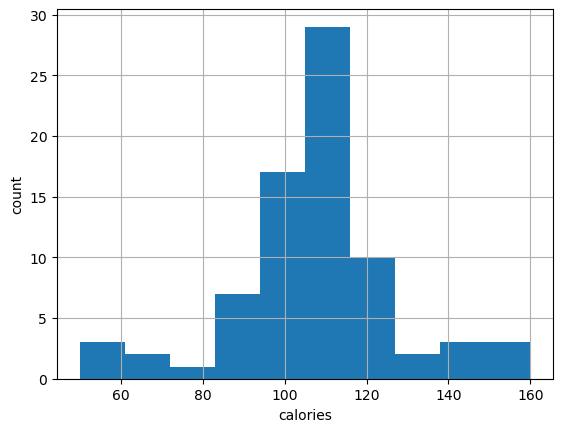

In [25]:
ax = cereals.calories.hist()
ax.set_xlabel('calories')
ax.set_ylabel('count')
plt.show()

I'm going to write a loop so I can quickly graph all 13 variables.

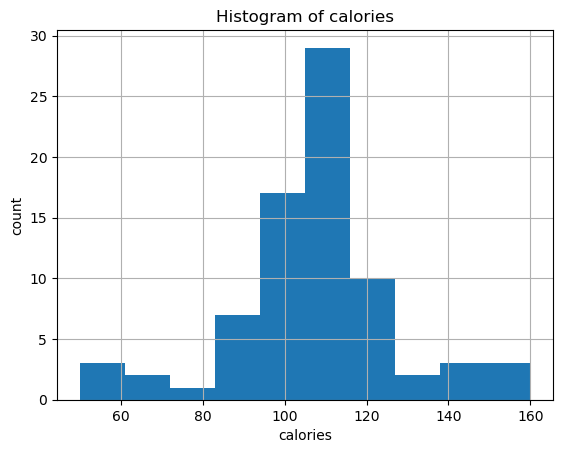

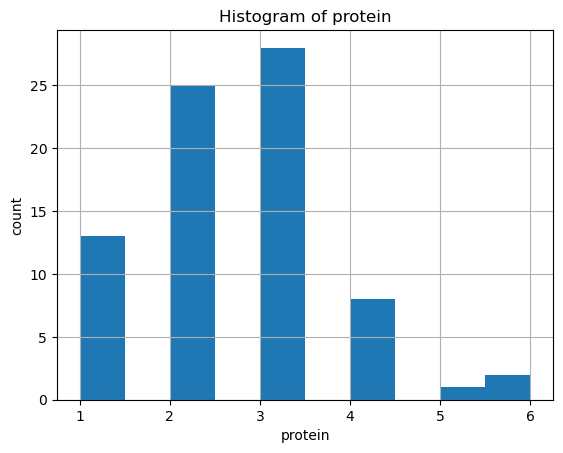

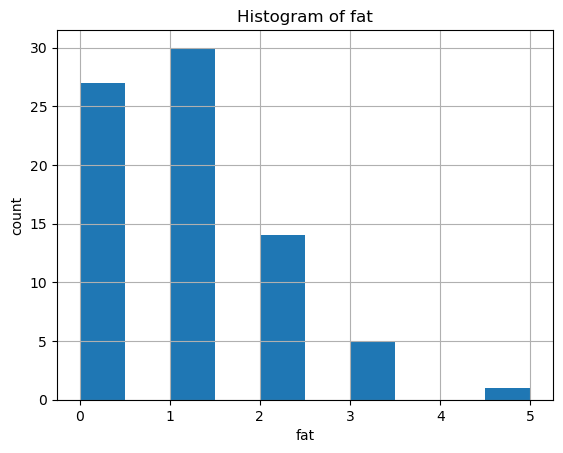

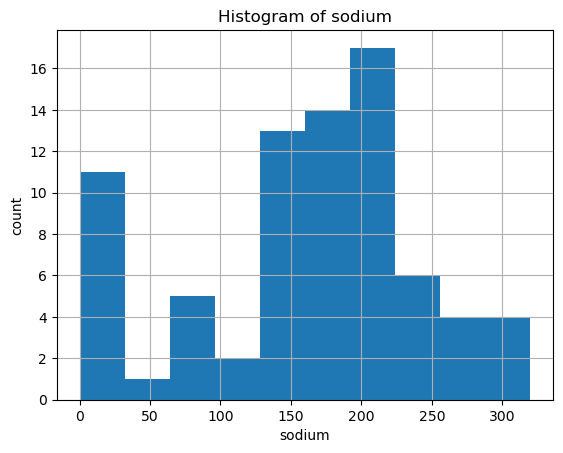

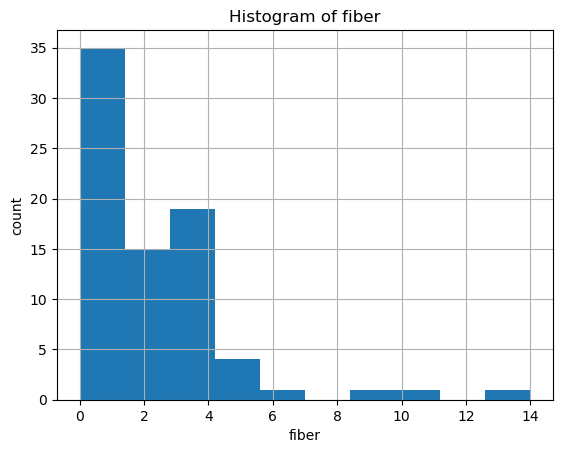

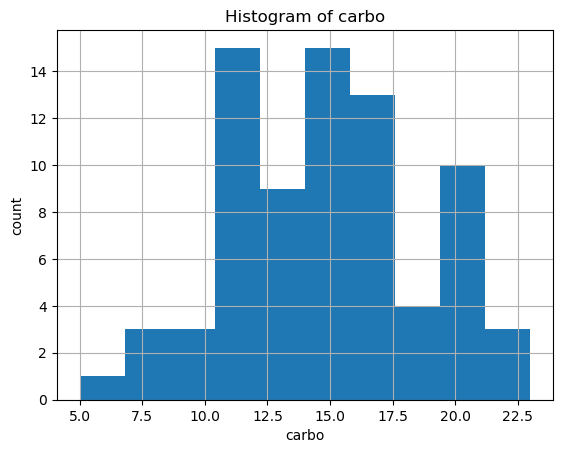

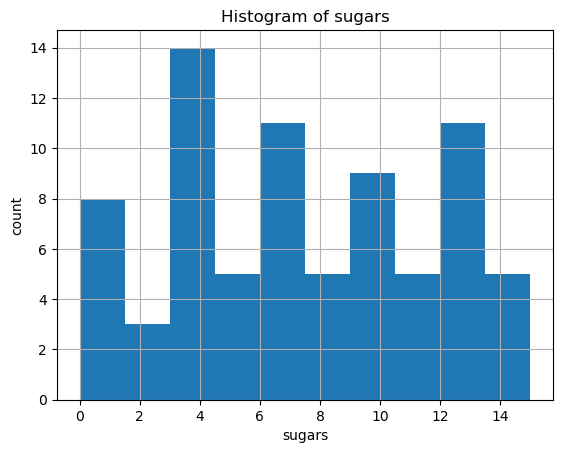

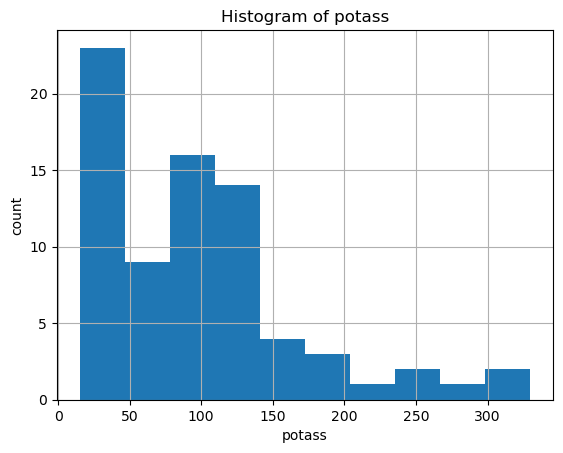

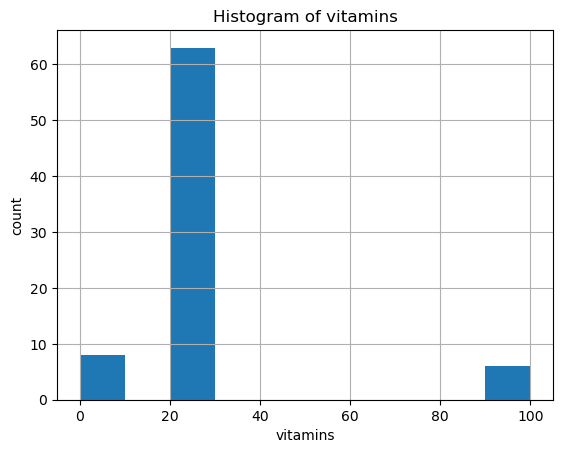

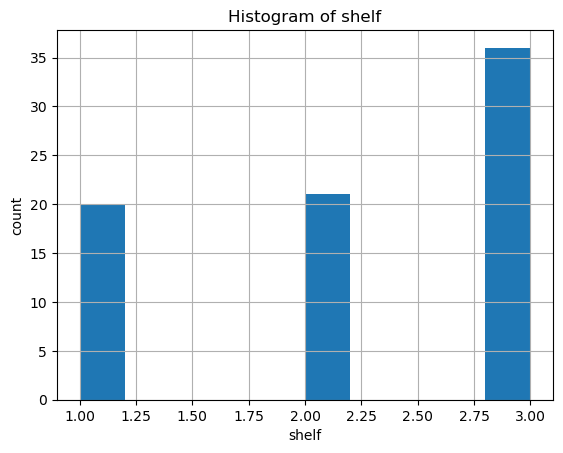

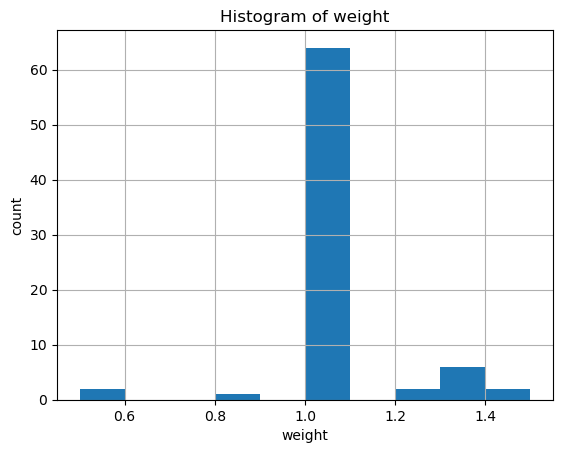

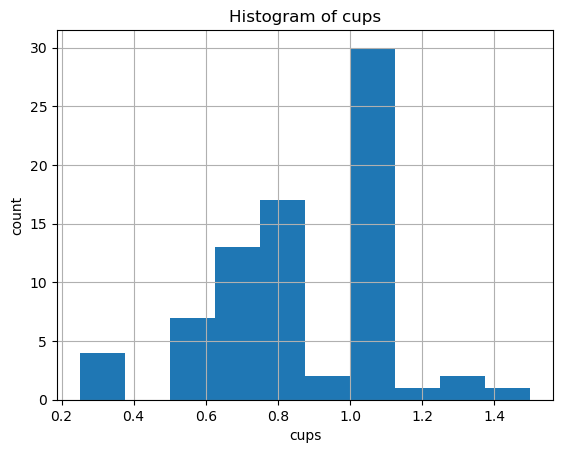

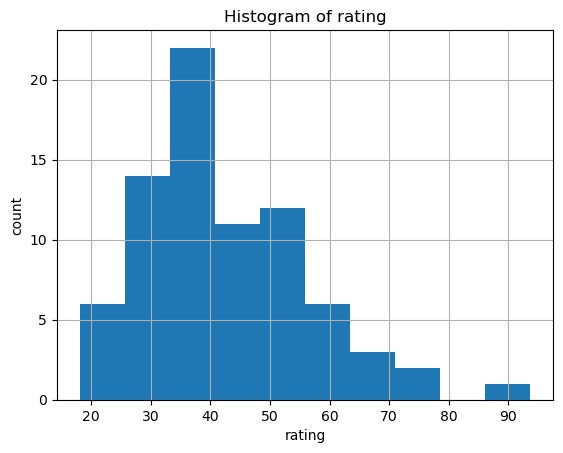

In [26]:
# Select all numeric variables
quant_vars = cereals.select_dtypes(include=['int64', 'float64'])

for col in quant_vars.columns:
    ax = cereals[col].hist()
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    plt.title(f'Histogram of {col}')
    plt.show()

#### i) Variables with Largest Variability
Looking at the histograms above: `sodium` and `potass` seem to have the largest variablility. Looking at the summary statistics, they also have the highest standard deviation.

#### ii) Skewed Variables
Using the histograms: `fiber`, `potass`, `fat`, and `rating` show large or slight skewness.

#### iii) Extreme Values
Possible outliers appear in `rating`, `weight`, `vitamins`, and possibly `fiber`. However, `fiber` has some grouping with other cereals that contain high fiber, it's not really an isolated bar.

#### D) Plot a side-by-side boxplot comparing the calories in hot vs. cold cereals. What does this plot show us?

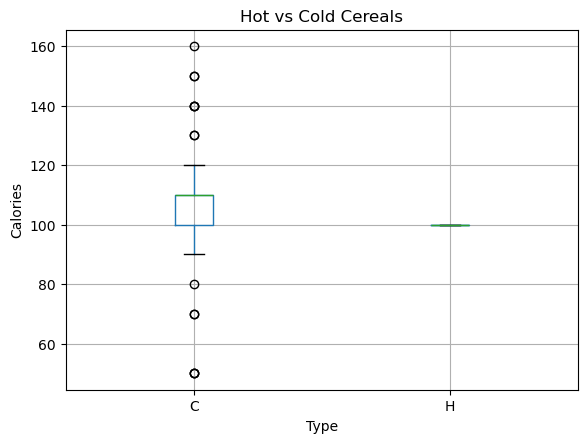

In [27]:
ax = cereals.boxplot(column='calories', by='type')
ax.set_ylabel('Calories')
ax.set_xlabel('Type')
plt.suptitle('')  # Suppress the titles
plt.title('Hot vs Cold Cereals')
plt.show()

We can see that cold cereals show much more variability because there are significantly more cold cereals in this data set than hot cereals. There are only a few hot cereals, so they are contained in a much smaller calorie range. Cold cereals also contains many outliers!

#### E) Plot a side-by-side boxplot of consumer rating as a function of the shelf height. If we were to predict consumer rating from shelf height, does it appear that we need to keep all three categories of shelf height?

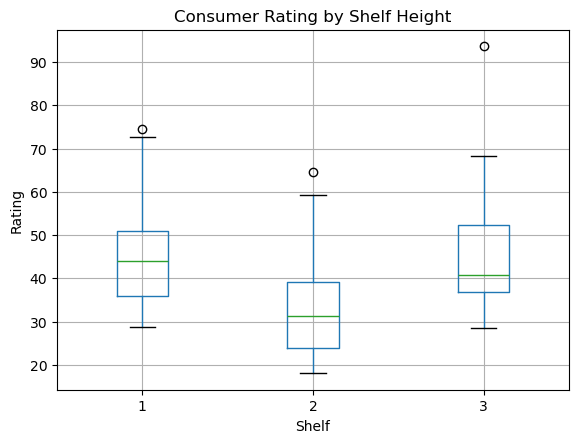

In [28]:
ax = cereals.boxplot(column='rating', by='shelf')
ax.set_ylabel('Rating')
ax.set_xlabel('Shelf')
plt.suptitle('')  # Suppress the titles
plt.title('Consumer Rating by Shelf Height')
plt.show()

Looking at the box plots, I think we are able to keep the three distinct groups for our analysis. Groups 1 and 3 are similar in their distribution, however, the average score and quantiles are different from eachother. Shelf 2 is completely distinct so it would not be grouped with either.

#### F)  Compute the correlation table for the quantitative variable (method corr()). In addition, generate a matrix plot for these variables.

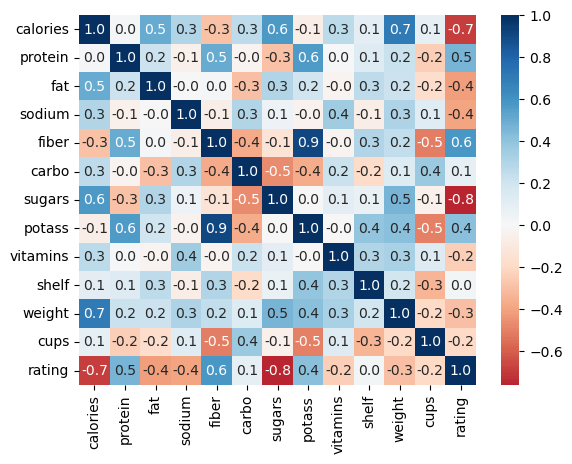

In [39]:
corr = quant_vars.corr().round(2)

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdBu", center=0, ax=ax)
plt.show()

#### i) Which pair of variables is most strongly correlated?
- `potass` and `fiber` have a very high posititve correlation
- `weight` and `calories` have a strong positive correlation
- `sugars` and `rating` have a strong negative correlation
- `calories` and `rating` have a strong negative correlation

#### ii) How can we reduce the number of variables based on these correlations?
If two variables are very highly correlated, this means we can try to remove one of the variable sto reduce redundancy. Removing highly correlated variables helps reduce multicollinearity.

#### iii) How would the correlations change if we normalized the data first?
If we normalized the data first (z-scores) the strength of the correlations will not change. The correlation depends on relative relationships between variables, so changing the scale of the variables does not change the correlations between variables.

#### G)  Consider the first PC of the analysis of the 13 numerical variables in Table 4.12. Describe briefly what this PC represents.

The first principal component (PC1) represents the highest source of variation, explaining about 53.95% of the total variance. Looking at the loadings in PC1, the variable sodium has a very large negative coefficient (-0.980), while most other variables have coefficients close to zero. There are also smaller contributions from potassium (positive) and calories/rating, but these are minor compared to sodium.

PC1 is essentially capturing a “sodium-driven” dimension in the data:

Cereals with high sodium will have low PC1 scores
Cereals with low sodium will have high PC1 scores

## 4.2
### University Rankings. The dataset `Universities.csv` on American college and university rankings

It contains information on 1302 American colleges and universities offering an undergraduate program. For each university, there are 17 measurements that include continuous measurements (such as tuition and graduation rate) and categorical measurements (such as location by state and whether it is a private or a public school).

#### A) Remove all categorical variables. Then remove all records with missing numerical measurements from the dataset.

In [30]:
universities = pd.read_csv("~/DS110/data/Universities.csv")

numeric_univ = universities.select_dtypes(include=['int64','float64'])

numeric_univ_clean = numeric_univ.dropna()

#### B) Conduct a principal components analysis on the cleaned data and comment on the results. Should the data be normalized?

Yes, the data must be normalized before PCA because:
* Variables are measured on different scales (tuition vs. graduation rate vs. enrollment).
* Without normalization, variables with larger magnitudes will dominate the principal components.
* Standardization ensures each variable contributes the same to the outcome.

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
univ_scaled = scaler.fit_transform(numeric_univ_clean)

pca = PCA()
pca.fit(univ_scaled)

pcaSummary = pd.DataFrame({
    'Standard deviation': np.sqrt(pca.explained_variance_),
    'Proportion of variance': pca.explained_variance_ratio_,
    'Cumulative proportion': np.cumsum(pca.explained_variance_ratio_)
})

pcaSummary = pcaSummary.transpose()
pcaSummary.columns = [f'PC{i}' for i in range(1, len(pcaSummary.columns)+1)]

print(pcaSummary.round(4))

                           PC1     PC2     PC3     PC4     PC5     PC6  \
Standard deviation      2.3673  2.1907  1.1113  1.0339  0.9919  0.8747   
Proportion of variance  0.3107  0.2661  0.0685  0.0593  0.0545  0.0424   
Cumulative proportion   0.3107  0.5767  0.6452  0.7045  0.7590  0.8014   

                           PC7     PC8     PC9    PC10    PC11    PC12  \
Standard deviation      0.8356  0.7736  0.7347  0.6634  0.6305  0.5853   
Proportion of variance  0.0387  0.0332  0.0299  0.0244  0.0220  0.0190   
Cumulative proportion   0.8401  0.8733  0.9032  0.9276  0.9497  0.9687   

                          PC13    PC14    PC15    PC16    PC17    PC18  
Standard deviation      0.4590  0.4382  0.3008  0.1892  0.1473  0.1199  
Proportion of variance  0.0117  0.0106  0.0050  0.0020  0.0012  0.0008  
Cumulative proportion   0.9804  0.9910  0.9960  0.9980  0.9992  1.0000  


## 4.3 
### The dataset `ToyotaCorolla.csv` contains data on used cars (Toyota Corollas) on sale during late summer of 2004 in the Netherlands. 

It has 1436 records containing details on 38 attributes, including Price, Age, Kilometers, HP, and other specifications. The goal will be to predict the price of a used Toyota Corolla based on its specifications.

In [33]:
toyota = pd.read_csv("~/DS110/data/ToyotaCorolla.csv")

toyota.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


#### A) Identify the categorical variables
Categorical variables are groups, categories, or labels that the variable can be grouped into. In our `ToyotaCorolla.csv` dataset, the categorical variables are:
- `Fuel_Type`
- `Met_Color`
- `Color`
- `Automatic`
- `Mfr_Guarantee`
- `Doors`
- `BOVAG_Guarantee`
- `Guarantee_Period`
- `ABS`
- `Airbag_1`
- `Airbag_2`
- `Airco`
- `Automatic_airco`
- `Boardcomputer`
- `CD_Player`
- `Central_Lock`
- `Powered_Windows`
- `Power_Steering`
- `Radio`
- `Mistlamps`
- `Sport_model`
- `Backseat_Divider`
- `Metallic_Rim`
- `Radio_Cassette`
- `Parking_Assistant`
- `Tow_Bar`

However, most are already binary encoded. We only need to create dummy variables to encode the categorical values for:
- `Fuel_Type`
- `Color`

#### B) Explain the relationship between a categorical variable and the series of binary dummy variables derived from it.
The model requires numerical inputs, so each categorical variable must be converting into binary dummy variables to encode each label. If a variable has multiple categories, each category is represented by a binary indicator variable (1 = in category, 0 = not).

#### C) How many dummy binary variables are required to capture the information in a categorical variable with categories?
For each categorical variable with k categories we create:
$$ k - 1 $$
dummary variables. The left out category is used as the "baseline" category for the model.

#### D) Use Python to convert the categorical variables in this dataset into dummy variables, and explain in words, for one record, the values in the derived binary dummies.
As we mentioned above, most of the categorical variables are already binary encoded. However we still need to create dummy variables for `Feul_Type` and for `Color`.

In [34]:
toyota = toyota.drop(columns=['Model'])

toyota = pd.get_dummies(toyota,
                            columns=['Fuel_Type','Color'],
                            drop_first=True)

toyota.head()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,1,13500,23,10,2002,46986,90,1,0,2000,...,False,False,True,False,False,False,False,False,False,False
1,2,13750,23,10,2002,72937,90,1,0,2000,...,False,False,False,False,False,False,True,False,False,False
2,3,13950,24,9,2002,41711,90,1,0,2000,...,False,False,True,False,False,False,False,False,False,False
3,4,14950,26,7,2002,48000,90,0,0,2000,...,False,True,False,False,False,False,False,False,False,False
4,5,13750,30,3,2002,38500,90,0,0,2000,...,False,True,False,False,False,False,False,False,False,False


The first car in our dataset had `Fuel_Type` = Diesel and `Color` = Blue. It has been encoded to:

`Fuel_Type_Petrol` = False
`Color_Black` = False
`Color_Green` = False
`Color_Grey` = False
`Color_Red` = False
`Color_Silver` = False
`Color_Violet` = False
`Color_White` = False
`Color_Yellow` = False

Everything is false becuase our first row's categories become our baseline. So `Fuel_Type_Diesel` and `Color_Blue` are inherently True when everything els eis false.

#### E) Use Python to produce a correlation matrix and matrix plot. Comment on the relationships among variables.

In [35]:
numeric_toyota = toyota[['Age_08_04','Mfg_Month','Mfg_Year','KM','HP','CC','Doors','Cylinders','Gears','Quarterly_Tax','Weight']].copy()

corr_matrix = numeric_toyota.corr().round(2)

print(corr_matrix)

               Age_08_04  Mfg_Month  Mfg_Year    KM    HP    CC  Doors  \
Age_08_04           1.00      -0.12     -0.98  0.51 -0.16 -0.10  -0.15   
Mfg_Month          -0.12       1.00     -0.06 -0.02 -0.04  0.04  -0.01   
Mfg_Year           -0.98      -0.06      1.00 -0.50  0.16  0.09   0.15   
KM                  0.51      -0.02     -0.50  1.00 -0.33  0.10  -0.04   
HP                 -0.16      -0.04      0.16 -0.33  1.00  0.04   0.09   
CC                 -0.10       0.04      0.09  0.10  0.04  1.00   0.08   
Doors              -0.15      -0.01      0.15 -0.04  0.09  0.08   1.00   
Cylinders            NaN        NaN       NaN   NaN   NaN   NaN    NaN   
Gears              -0.01      -0.01      0.01  0.02  0.21  0.01  -0.16   
Quarterly_Tax      -0.20       0.03      0.19  0.28 -0.30  0.31   0.11   
Weight             -0.47      -0.00      0.47 -0.03  0.09  0.34   0.30   

               Cylinders  Gears  Quarterly_Tax  Weight  
Age_08_04            NaN  -0.01          -0.20   -0.47

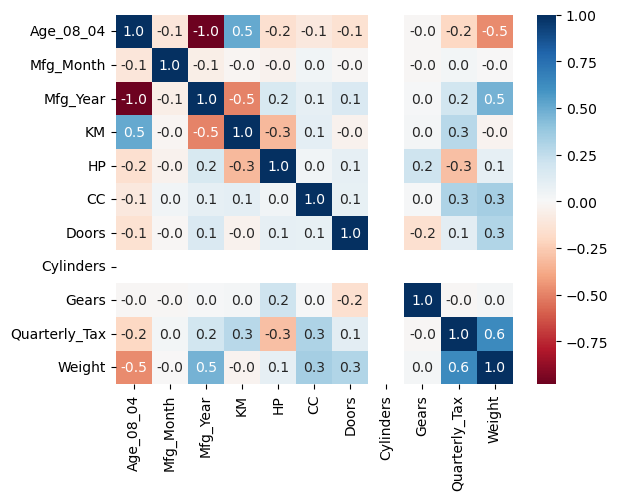

In [36]:
fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="RdBu", center=0, ax=ax)
plt.show()

There are only one highly correlated variables:
- `Mfg_Year` and `Age_08_04` are highly negatively correlated.